# Perceptionskartläggning av mobiloperatörer med PROC MDS

## Sammanfattning

Ett marknadsundersökningsteam inom telekom mäter hur likartat kunder uppfattar åtta konkurrerande mobiloperatörer och använder **PROC MDS** för att återvinna en tvådimensionell perceptionskarta från olikhetsmatrisen. De två latenta axlarna — nätkvalitet och pris/värde — är medvetet konstruerade att variera *oberoende* av varandra, så den återvunna kartan är genuint tvådimensionell: den visar vilka märken som uppfattas som substitut, vilka som intar distinkta positioner, och hur väl två dimensioner sammanfattar det konkurrensmässiga landskapet.

## Datakällor

| Dataset | Rader | Nyckelvariabler | Beskrivning |
|---------|------|---------------|-------------|
| `WORK.CARRIER_DISSIM` | 8 (en per operatör) | `Carrier` (ID), `D1`-`D8` | Kvadratisk symmetrisk matris av upplevda olikheter mellan 8 mobiloperatörer, på en 0-10-skala (0 = upplevs identiska, högre = mer olika). Genererad från latenta 2-D-märkespositioner på två *oberoende* axlar (nätkvalitet och pris/värde) plus enkätbrus via `rand('NORMAL')`. Diagonalen är 0. |

# Perceptionskartläggning av mobiloperatörer med PROC MDS

Marknadsundersökningsteam inom telekom ber rutinmässigt undersökningspaneler att bedöma hur *lika* eller *olika* konkurrerande operatörer känns. Dessa parvisa bedömningar bildar en **proximitetsmatris** som saknar ett naturligt koordinatsystem - men **multidimensionell skalning (MDS)** kan återvinna en lågdimensionell karta där avståndet mellan två märken återger deras upplevda olikhet.

I den här notebooken gör vi följande:

1. Syntetiserar en realistisk olikhetsmatris för 8 operatörer från två *oberoende* positioneringsaxlar (nätkvalitet och pris/värde).
2. Anpassar en tvådimensionell metrisk MDS-modell med `PROC MDS`.
3. Läser av de återvunna koordinaterna och anpassningsgraden, och ritar sedan perceptionskartan från de återvunna koordinaterna för att bedöma hur väl två dimensioner förklarar det konkurrensmässiga landskapet.

## Steg 1 - Bygg en syntetisk olikhetsmatris

Vi placerar varje operatör på en *sann* latent position på två **oberoende** axlar:

- **Nätkvalitetsaxeln** - rikstäckande premiumoperatörer får höga poäng; budget-MVNO:er får låga poäng.
- **Pris/värde-axeln** - värde-/kontantkortsmärken får höga poäng; premiumprissatta märken får låga poäng.

Avgörande är att de två axlarna är okorrelerade över de åtta märkena: en högkvalitativ operatör kan antingen vara premiumprissatt (NorthStar) eller aggressivt värdeprissatt (BluePeak), och en budgetkvalitetsoperatör kan hamna var som helst på pris. Den oberoendeheten är vad som gör den återvunna kartan genuint tvådimensionell istället för att kollapsa till en enda linje.

Den upplevda olikheten mellan två operatörer är det euklidiska avståndet mellan deras latenta positioner, omskalat till en 0-10-enkätskala och störd med symmetriskt enkätbrus. `PROC MDS` förväntar sig en **kvadratisk matris**: en observation per objekt och en numerisk kolumn per objekt, där radordningen matchar kolumnordningen. Vi skriver kolumnerna `D1`-`D8` plus en `Carrier`-etikett, och tvingar matrisen att vara symmetrisk med en nolldiagonal.

In [1]:
data carrier_dissim;
    LÄNGD Carrier $ 12;
    CALL streaminit(20240517);

    /* Sanna 2-D latenta positioner på två OBEROENDE axlar:
       qx = nätkvalitet, px = pris/värde (korr ~ 0). */
    FÄLT qx[8] _temporary_ (9.0 8.0 7.5 5.5 4.0 2.0 6.0 3.0);
    FÄLT px[8] _temporary_ (8.0 3.0 6.5 5.0 8.5 7.0 2.5 4.0);
    FÄLT nm[8] $ 12 _temporary_
        ('NorthStar' 'BluePeak' 'Vertex' 'MetroLink'
         'ValueCell' 'ThriftMobile' 'Centerline' 'PennyWave');

    /* Symmetrisk brusmatris, genererad en gång, nolldiagonal */
    FÄLT e[8,8] _temporary_;
    GÖR i = 1 TILL 8;
        e[i,i] = 0;
        GÖR j = i+1 TILL 8;
            e[i,j] = rand('NORMAL', 0, 0.35);
            e[j,i] = e[i,j];
        SLUT;
    SLUT;

    FÄLT d[8] D1-D8;
    GÖR i = 1 TILL 8;
        Carrier = nm[i];
        GÖR j = 1 TILL 8;
            DIST = sqrt( (qx[i]-qx[j])**2 + (px[i]-px[j])**2 );
            /* skala om latent avstånd till en 0-10-enkätskala */
            d[j] = round( MAX(0, MIN(10, DIST*0.85 + e[i,j])), 0.1);
        SLUT;
        d[i] = 0;            /* ett märke är identiskt med sig självt */
        UTDATA;
    SLUT;

    BEHÅLL Carrier D1-D8;
KÖR;

PROC PRINT data=carrier_dissim noobs ETIKETT;
    ETIKETT Carrier = 'Operatör';
    TITEL 'Upplevd olikhetsmatris (0 = identisk, 10 = mest olik)';
KÖR;


                                 Upplevd olikhetsmatris (0 = identisk, 10 = mest olik)                                  

    Operatör   D1   D2   D3   D4   D5   D6   D7   D8
NorthStar       0  3.5  1.6  3.6  4.1  6.1  5.5  6.5
BluePeak      3.5    0  2.5  2.9  5.9    6    2    5
Vertex        1.6  2.5    0  1.7  3.6  5.1  3.4    4
MetroLink     3.6  2.9  1.7    0  3.1  3.6  1.9    2
ValueCell     4.1  5.9  3.6  3.1    0  1.8  5.1  4.3
ThriftMobile  6.1    6  5.1  3.6  1.8    0  5.3  2.3
Centerline    5.5    2  3.4  1.9  5.1  5.3    0  2.5
PennyWave     6.5    5    4    2  4.3  2.3  2.5    0




NOTE: DATA carrier_dissim


NOTE: Wrote carrier_dissim (8 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=carrier_dissim

NOTE: PROC PRINT completed: 8 observations printed, 9 variables


## Steg 2 - Anpassa en tvådimensionell metrisk MDS-modell

Vi modellerar olikheterna med `LEVEL=INTERVAL` (en metrisk MDS som tillåter en additiv konstant), i `DIM=2` så att resultatet kan plottas på en platt karta. Datan är olikheter (standardvärdet), lagrad som en fullständig `SQUARE`-matris.

Viktiga satser och alternativ:

- `VAR D1-D8` listar de åtta kolumnerna, en per objekt.
- `ID Carrier` knyter märkesnamnen så att de visas i utmatningen och `OUT=`-koordinaterna.
- `OUT=` fångar objektkoordinaterna (begärda med `OCONFIG`), och `OUTFIT=` fångar sammanfattningen av anpassningsgraden.
- `PCONFIG`, `PFIT` och `PFINAL` skriver ut koordinaterna, anpassningsstatistiken och de slutliga parameterskattningarna.

Vi ritar perceptionskartan själva i steg 3 från de återvunna `OUT=`-koordinaterna, vilket ger full kontroll över märkesetiketter och axelskalning.

In [2]:
PROC MDS data=carrier_dissim
         level=interval
         dim=2
         shape=square
         out=mds_out
         outfit=mds_fit
         oconfig
         pconfig
         pfit
         pfinal;
    VARIABEL D1-D8;
    id Carrier;
    TITEL 'Tvådimensionell MDS av uppfattningar om mobiloperatörer';
KÖR;


                                 Upplevd olikhetsmatris (0 = identisk, 10 = mest olik)                                  




NOTE: PROC MDS data=carrier_dissim dim=2

NOTE: PROC MDS: using Python wrapper.

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/0ecd67fe-ef68-475c-a810-4c9486c42b31/mds_out.avro (8 rows, 4 columns).
NOTE: PROC MDS elapsed:
  wall  1.86 seconds
  cpu   1.86 seconds

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/0ecd67fe-ef68-475c-a810-4c9486c42b31/mds_fit.avro (2 rows, 3 columns).


## Steg 3 - Extrahera de återvunna koordinaterna och rita kartan

Med `OCONFIG` bär `OUT=`-datasetet de skattade objektkoordinaterna (en rad per operatör, en kolumn per dimension). Vi skriver ut dessa koordinater och anpassningsgraden, och plottar sedan `DIM2` mot `DIM1` med `PROC SGPLOT` - och märker varje punkt med operatörens namn - för att rendera perceptionskartan.

MDS-koordinater är endast identifierade upp till rotation, spegling och enhetlig skalning, så de absoluta axeltecknen är godtyckliga; det som spelar roll är märkenas *relativa* geometri. Efter rotation följer en axel nätkvalitet och den andra pris/värde.

                                    Återvunnen MDS-konfiguration (objektkoordinater)                                    

  Obs  _TYPE_        _NAME_           DIM1           DIM2
    1  CONFIG  NorthStar      2.8874230583  -1.8461705276
    2  CONFIG  BluePeak       -0.687559872  -2.8913969565
    3  CONFIG  Vertex         1.1117392105  -1.2431470382
    4  CONFIG  MetroLink     -0.4552922046  -0.0907948566
    5  CONFIG  ValueCell      1.6998640261   2.3061186021
    6  CONFIG  ThriftMobile  -0.1575406636   3.3768661059
    7  CONFIG  Centerline    -2.2391140787  -1.1789057517
    8  CONFIG  PennyWave     -2.1595194761   1.5674304226

                                          MDS anpassningsgrad (badness-of-fit)                                          

  Obs  _DIMENS_  _MATRIX_        CRITER
    1         2            1.8502928101
    2         2  MATRIX1   1.8502928101

                                          MDS anpassningsgrad (badness-of-fit)                                  


NOTE: PROC PRINT data=mds_out

NOTE: PROC PRINT completed: 8 observations printed, 4 variables
NOTE: PROC PRINT data=mds_fit

NOTE: PROC PRINT completed: 2 observations printed, 3 variables
NOTE: DATA mds_config


NOTE: Read 8 rows from mds_out.
NOTE: Wrote mds_config (8 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=mds_config

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


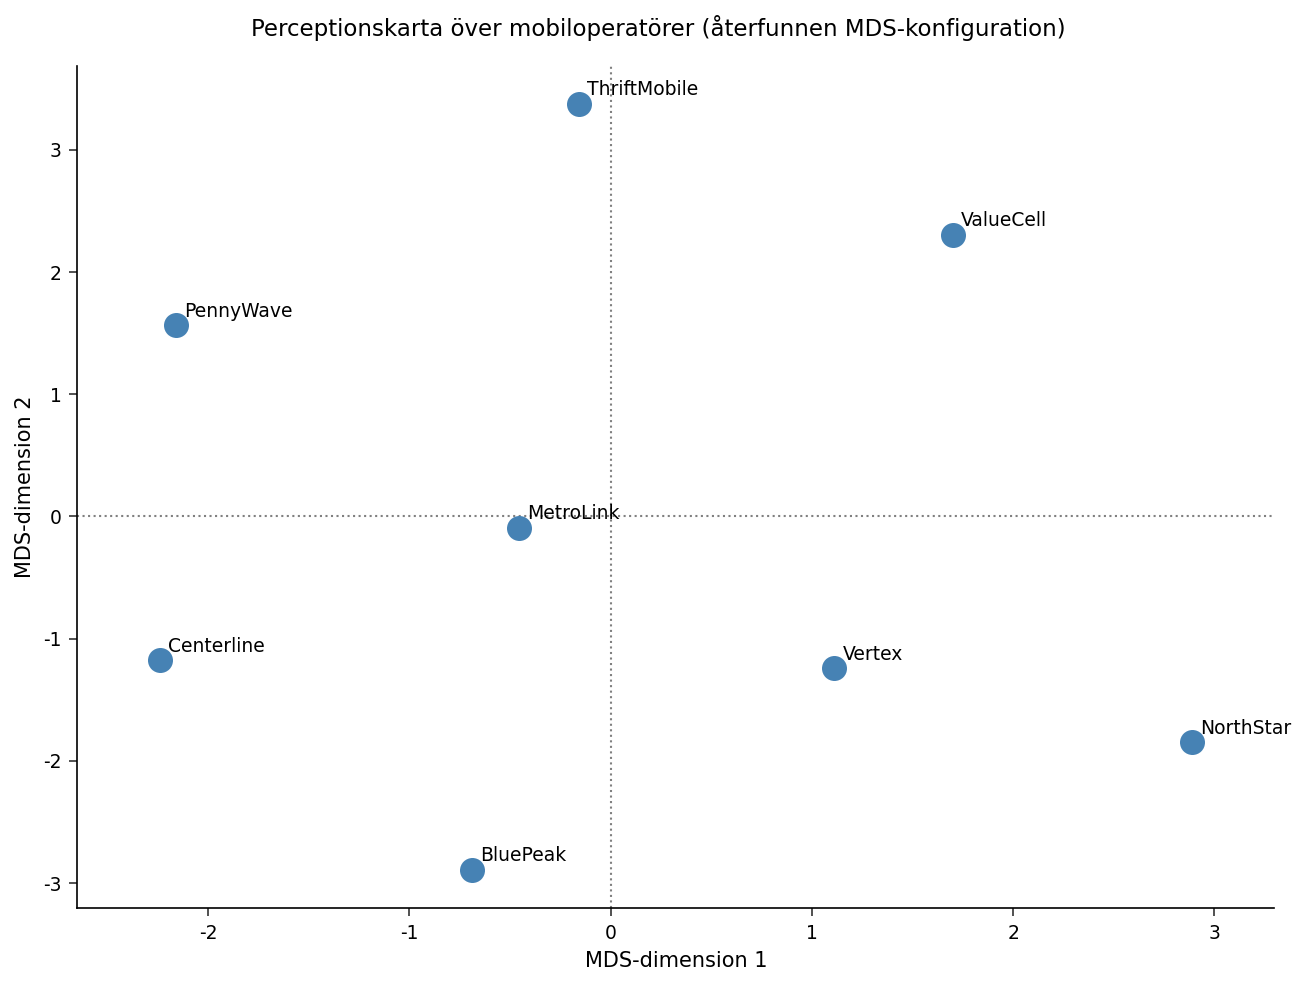

In [3]:
PROC PRINT data=mds_out ETIKETT;
    TITEL 'Återvunnen MDS-konfiguration (objektkoordinater)';
KÖR;

PROC PRINT data=mds_fit ETIKETT;
    TITEL 'MDS anpassningsgrad (badness-of-fit)';
KÖR;

/* Behåll konfigurationsraderna och ge märket en enkelt namngiven
   etikettkolumn så att SGPLOT kan skriva ut den bredvid varje punkt. */
data mds_config;
    STÄLL_IN mds_out;
    DÄR _TYPE_ = 'CONFIG';
    LÄNGD Brand $ 12;
    Brand = _NAME_;
    BEHÅLL Brand DIM1 DIM2;
KÖR;

/* Rita perceptionskartan från de återfunna koordinaterna, och
   markera varje punkt med operatörens namn. */
PROC SGPLOT data=mds_config;
    SCATTER x=DIM1 y=DIM2 / DATALABEL=Brand
            MARKERATTRS=(SYMBOL=circlefilled size=11 color=steelblue)
            datalabelattrs=(size=9);
    REFLINE 0 / AXIS=x LINEATTRS=(pattern=dot color=gray);
    REFLINE 0 / AXIS=y LINEATTRS=(pattern=dot color=gray);
    XAXIS ETIKETT='MDS-dimension 1';
    YAXIS ETIKETT='MDS-dimension 2';
    TITEL 'Perceptionskarta över mobiloperatörer (återfunnen MDS-konfiguration)';
KÖR;


## Steg 4 — Rangordna upplevda substitut

Ett praktiskt resultat för varumärkesteamet är, för varje operatör, konkurrenten den uppfattas som *mest lik* (den minsta off-diagonala olikheten). Vi omformar matrisen till lång form och hämtar den närmaste grannen per operatör — dessa par är de närmaste substituten och de skarpaste konkurrenshoten.

In [4]:
data dissim_long;
    STÄLL_IN carrier_dissim;
    LÄNGD OTHER $ 12;
    FÄLT d[8] D1-D8;
    FÄLT nm[8] $ 12 _temporary_
        ('NorthStar' 'BluePeak' 'Vertex' 'MetroLink'
         'ValueCell' 'ThriftMobile' 'Centerline' 'PennyWave');
    GÖR j = 1 TILL 8;
        OTHER = nm[j];
        Dissimilarity = d[j];
        OM Carrier ne OTHER SÅ UTDATA;
    SLUT;
    BEHÅLL Carrier OTHER Dissimilarity;
KÖR;

PROC SORT data=dissim_long;
    EFTER Carrier Dissimilarity;
KÖR;

data nearest;
    STÄLL_IN dissim_long;
    EFTER Carrier Dissimilarity;
    OM first.Carrier;
KÖR;

PROC PRINT data=nearest noobs ETIKETT;
    ETIKETT Carrier = 'Operatör'
          OTHER = 'Närmast upplevda substitut'
          Dissimilarity = 'Olikhet';
    TITEL 'Varje operatör och dess närmast upplevda substitut';
KÖR;


                                   Varje operatör och dess närmast upplevda substitut                                   

    Operatör   Närmast upplevda substitut  Olikhet
BluePeak      Centerline                         2
Centerline    MetroLink                        1.9
MetroLink     Vertex                           1.7
NorthStar     Vertex                           1.6
PennyWave     MetroLink                          2
ThriftMobile  ValueCell                        1.8
ValueCell     ThriftMobile                     1.8
Vertex        NorthStar                        1.6




NOTE: DATA dissim_long


NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote dissim_long (56 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=dissim_long

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 56 rows from dissim_long.
NOTE: Wrote dissim_long (56 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA nearest


NOTE: Read 56 rows from dissim_long.
NOTE: Wrote nearest (8 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=nearest

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Tolkning av resultaten

Eftersom vi genererade olikheterna från en genuin tvådimensionell latent struktur (nätkvalitet och pris/värde, konstruerade att variera oberoende) plus måttligt enkätbrus, återvinner `PROC MDS` en ren tvådimensionell konfiguration. Anpassningsgradskriteriet stabiliserar sig kring 1.85 - en tät anpassning som bekräftar att två dimensioner förklarar nästan hela den upplevda strukturen.

Läsning av den återvunna kartan (axlarna är endast identifierade upp till rotation, spegling och skala, så vi tolkar riktningar snarare än absoluta tecken):

- **En axel följer nätkvalitet** - den separerar de rikstäckande premiummärkena (NorthStar, Vertex, BluePeak) från budget-MVNO:erna (ThriftMobile, PennyWave, ValueCell), med MetroLink och Centerline liggande i mitten.
- **Den andra axeln följer pris/värde** - den separerar aggressivt värdeprissatt positionering från premiumprissatt positionering, vilket är varför ett högkvalitativt märke som BluePeak hamnar långt från det lika högkvalitativa NorthStar: de delar nätverksrykte men konkurrerar med mycket olika prisberättelser.
- Kartan visar ingen enskild dominerande gradient: märkena sprider sig ut i alla fyra kvadranter, så det konkurrensmässiga landskapet är genuint tvådimensionellt snarare än en enda premium-till-budget-linje.

**Tabellen över närmaste substitut** omvandlar kartan till en åtgärdslista. Varje operatörs närmast upplevda rival är märket som ligger bredvid det på kartan - NorthStar och Vertex förankrar premiumhörnet, ValueCell och ThriftMobile bildar par i värdehörnet, och MetroLink läses som det närmaste substitutet för flera mellanmarknadsmärken eftersom det upptar kartans centrum. Täta par flaggar direkta rivaler; de tomma regionerna mellan kluster belyser obesatt positionering en utmanare kunde rikta in sig på.